In [4]:
# # This Python 3 environment comes with many helpful analytics libraries installed
# # It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# # For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# # Input data files are available in the read-only "../input/" directory
# # For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# # You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# # You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# # Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# # Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

# import kagglehub
# # kagglehub.dataset_download('<owner>/<dataset-slug>')

# 📊 Seaborn 

## Statistical Data Visualization with Python

In this notebook, we will learn how to create beautiful statistical visualizations using Seaborn and perform basic Exploratory Data Analysis (EDA).

---

### 🎯 Learning Objectives

By the end of this notebook, you will be able to:

- Import and use Seaborn
- Load built-in datasets
- Understand different plot types
- Visualize numerical and categorical data
- Identify relationships between variables
- Create publication-ready graphs

---

**Prerequisites**

✔ Basic Python

✔ NumPy

✔ Pandas

Let's start!

# 📌 What is Seaborn?

Seaborn is a Python data visualization library built on top of Matplotlib.

It provides:

- Beautiful default themes
- Statistical visualizations
- Easy integration with Pandas DataFrames
- Simple syntax with powerful customization


# 📚 Import Required Libraries

Before creating visualizations, we need to import the required Python libraries.

We will use:

- NumPy → Numerical computations
- Pandas → Data manipulation
- Matplotlib → Basic plotting
- Seaborn → Statistical visualization

In [5]:
# Import required libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
print("Seaborn Version:", sns.__version__)

Seaborn Version: 0.13.2


# 🎨 Setting the Seaborn Theme

Seaborn provides attractive built-in themes.

Using a theme makes graphs:

- More readable
- More professional
- Easier to understand

The **darkgrid** style is commonly used for statistical analysis.

In [7]:
sns.set_theme(style="darkgrid")

# 📂 Loading the Dataset

Seaborn provides several built-in datasets for learning.

We will use the **Tips Dataset**, which contains restaurant billing information.

Each row represents one customer bill.

In [8]:
# Load built-in dataset

tips = pd.read_csv("./tip.csv")


# 🔍 Understanding the Dataset

Before visualization, we should understand our data.

Let's check:

- Number of rows
- Number of columns
- Data types
- Missing values

This process is called **Exploratory Data Analysis (EDA)**.

In [9]:
# Display first five rows

tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [10]:
# Display last five rows

tips.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [11]:
# Number of rows and columns

tips.shape

(244, 7)

In [12]:
tips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [13]:
tips.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [14]:
tips.isnull().sum()

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

# 📊 Histogram

A Histogram is used to visualize the distribution of numerical data.

### Question

How are restaurant bills distributed?

The x-axis represents the bill amount.

The y-axis represents the frequency (number of customers).

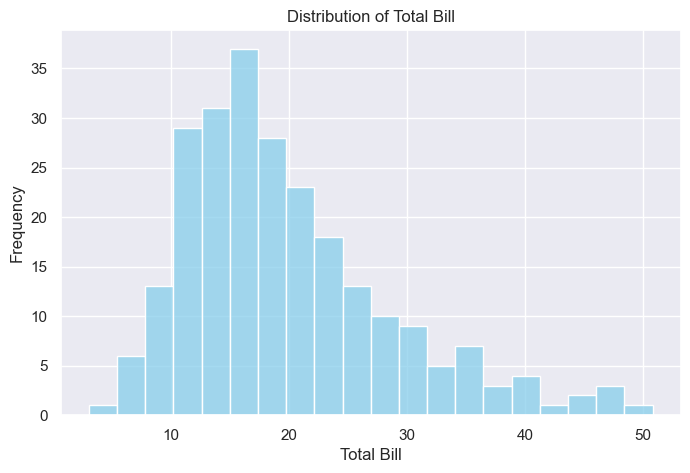

In [15]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=tips,
    x="total_bill",
    bins=20,
    color="skyblue"
)

plt.title("Distribution of Total Bill")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.show()

# 📈 Histogram with KDE

Previously, we created a Histogram to visualize the distribution of restaurant bills.

Now, let's enhance it by adding a **Kernel Density Estimate (KDE)** curve.

## What is KDE?

KDE (Kernel Density Estimate) is a smooth curve that represents the probability distribution of the data.

Instead of looking only at bars, KDE helps us understand where the data is concentrated.

### Question

Where do most restaurant bills lie?

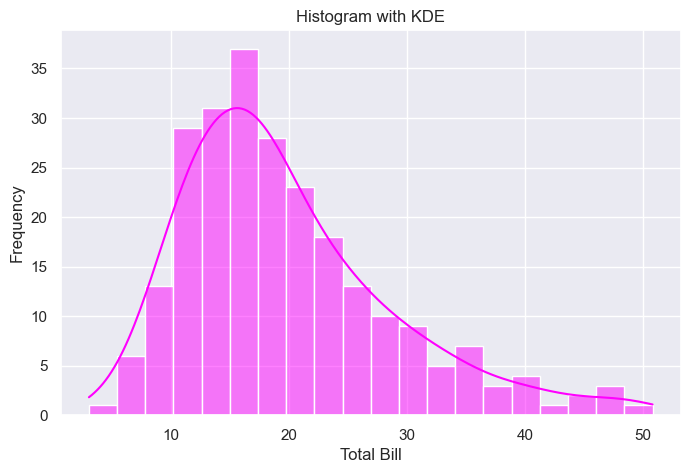

In [25]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=tips,
    x="total_bill",
    bins=20,
    kde=True,
    color="#ff00ff"
)

plt.title("Histogram with KDE")
plt.xlabel("Total Bill")
plt.ylabel("Frequency")

plt.show()

# 📊 Count Plot

A Count Plot is used to visualize **categorical variables**.

Instead of showing averages, it simply counts the number of observations in each category.

### Question

Which day has the highest number of customers?

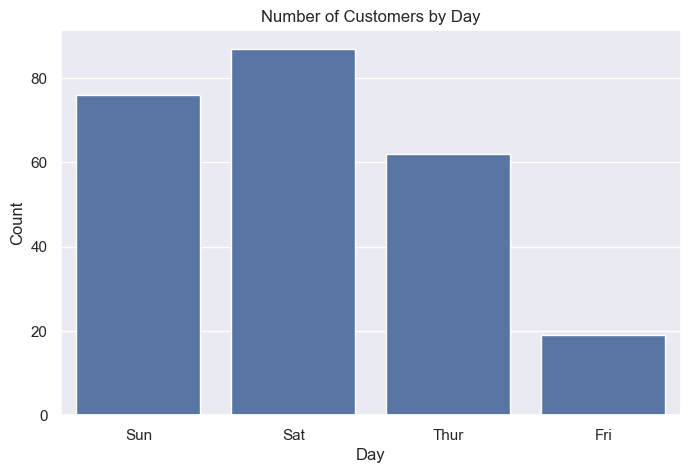

In [17]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=tips,
    x="day"
)

plt.title("Number of Customers by Day")
plt.xlabel("Day")
plt.ylabel("Count")

plt.show()

# 📦 Box Plot

Box Plot summarizes numerical data using:

- Minimum
- First Quartile (Q1)
- Median
- Third Quartile (Q3)
- Maximum
- Outliers

### Question

Which day has the highest bill variation?

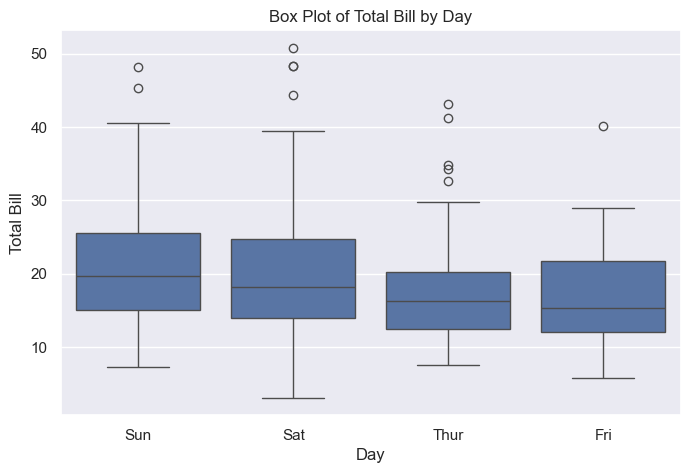

In [18]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=tips,
    x="day",
    y="total_bill",
)

plt.title("Box Plot of Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")

plt.show()

# 🎻 Violin Plot

A Violin Plot combines the features of a **Box Plot** and a **Density Plot**.

It not only shows the summary statistics but also displays the distribution of the data.

### Why use a Violin Plot?

- Shows Median
- Shows Distribution Shape
- Helps compare multiple categories

### Question

Which day has the widest distribution of restaurant bills?

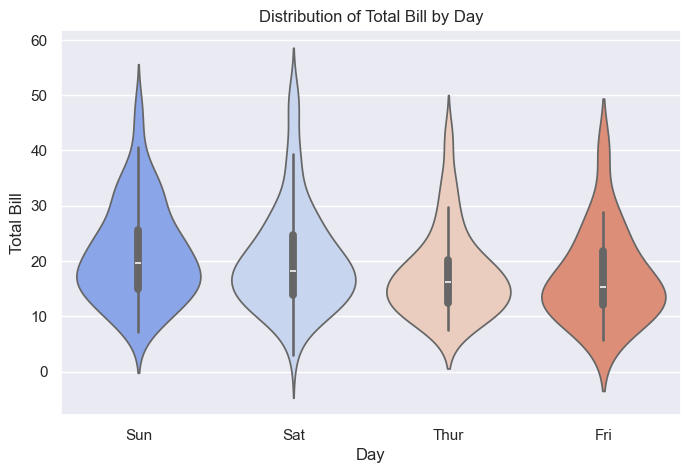

In [19]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=tips,
    x="day",
    y="total_bill",
    hue="day",
    palette="coolwarm",
    legend=False
)

plt.title("Distribution of Total Bill by Day")
plt.xlabel("Day")
plt.ylabel("Total Bill")

plt.show()

# 📉 Regression Plot

Regression Plot helps us identify the relationship between two numerical variables.

It combines:

- Scatter Plot
- Best Fit Line

### Question

Does a higher restaurant bill generally result in a higher tip?

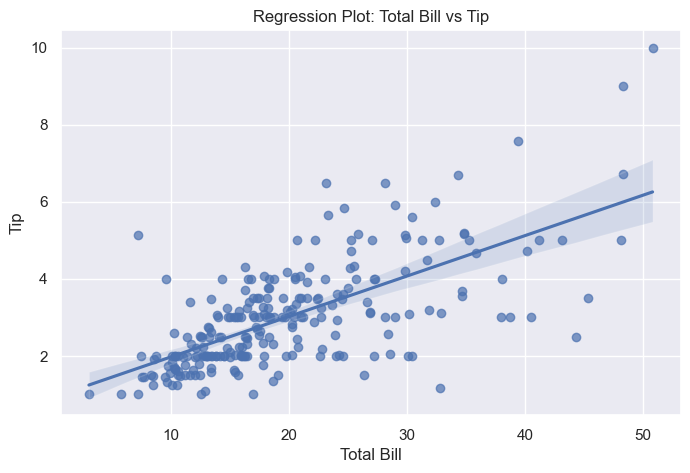

In [20]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=tips,
    x="total_bill",
    y="tip",
    scatter_kws={"alpha":0.7}
)

plt.title("Regression Plot: Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")

plt.show()

# 🔥 Correlation Matrix

Correlation measures the strength of the relationship between numerical variables.

Correlation values range from:

| Value | Meaning |
|-------------|----------------|
| +1 | Strong Positive Correlation |
| 0 | No Correlation |
| -1 | Strong Negative Correlation |

We will first calculate the correlation matrix and then visualize it using a Heatmap.

In [21]:
# Select numerical columns

numeric_data = tips.select_dtypes(include="number")

# Calculate correlation matrix

corr_matrix = numeric_data.corr()

corr_matrix

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


# 🌡 Heatmap

A Heatmap represents values using colors.

Darker colors generally indicate stronger relationships.

Heatmaps are one of the most commonly used visualizations in Data Science.

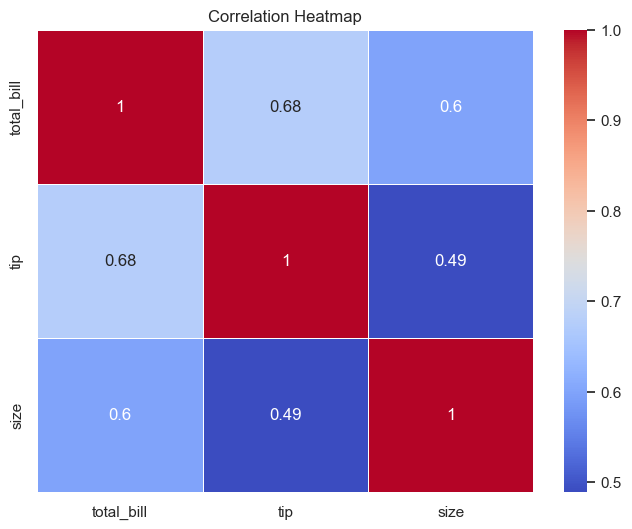

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")

plt.show()